In [1]:
# PROBLEM STATEMENT
# The objective of this project is to predict the next day's closing
# stock price using historical stock market data obtained from Yahoo Finance.

!pip install yfinance --quiet

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2021-01-01",
    end="2026-01-01"
)

df.head()

/tmp/ipykernel_2398/1775115451.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740852,129.821767,123.165986,129.734322,143301900
2021-01-05,127.295486,128.004800,124.788635,125.235599,97664900
2021-01-06,123.010536,127.334371,122.796773,124.098784,155088000
2021-01-07,127.208069,127.897945,124.234830,124.720654,109578200
2021-01-08,128.305984,128.869542,126.537580,128.675200,105158200


In [ ]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1255, 5)


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740852,129.821767,123.165986,129.734322,143301900
2021-01-05,127.295486,128.004800,124.788635,125.235599,97664900
2021-01-06,123.010536,127.334371,122.796773,124.098784,155088000
2021-01-07,127.208069,127.897945,124.234830,124.720654,109578200
2021-01-08,128.305984,128.869542,126.537580,128.675200,105158200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,179.208305,180.971766,177.268527,179.030417,6.981550e+07
std,40.018106,40.242869,39.736256,39.969815,2.996296e+07
min,113.229805,117.161110,113.083839,115.827984,1.791060e+07
25%,145.820114,147.471797,144.374754,145.642471,4.834280e+07
50%,171.363174,172.895120,169.496071,171.194027,6.313550e+07
75%,210.315628,212.380269,207.714146,209.737933,8.453615e+07
max,285.659271,288.084759,282.774617,285.669263,3.186799e+08


In [ ]:
df["Next_Close"] = df["Close"].shift(-1)

df.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2021-01-04,125.740852,129.821767,123.165986,129.734322,143301900,127.295486
2021-01-05,127.295486,128.004800,124.788635,125.235599,97664900,123.010536
2021-01-06,123.010536,127.334371,122.796773,124.098784,155088000,127.208069
2021-01-07,127.208069,127.897945,124.234830,124.720654,109578200,128.305984
2021-01-08,128.305984,128.869542,126.537580,128.675200,105158200,125.323021


In [ ]:
df.dropna(inplace=True)

In [ ]:
X = df[[
    "Open",
    "High",
    "Low",
    "Volume"
]]

y = df["Next_Close"]

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1003
Testing Samples: 251


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 3.0929512132466606


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 4.525609346688194


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9708169100718713


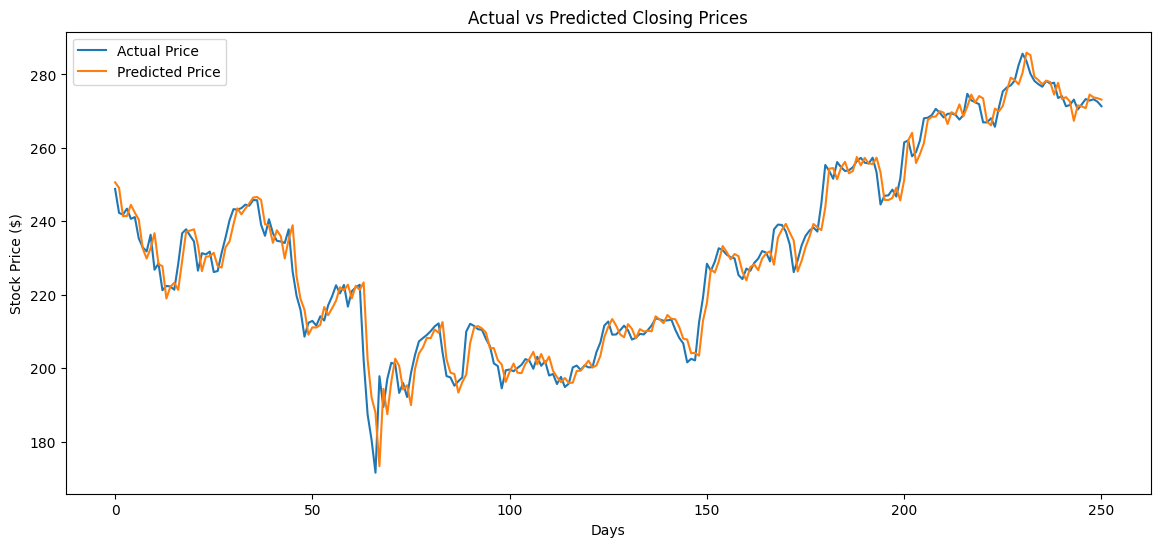

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual Price"
)

plt.plot(
    y_pred,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Closing Prices")

plt.xlabel("Days")

plt.ylabel("Stock Price ($)")

plt.legend()

plt.show()

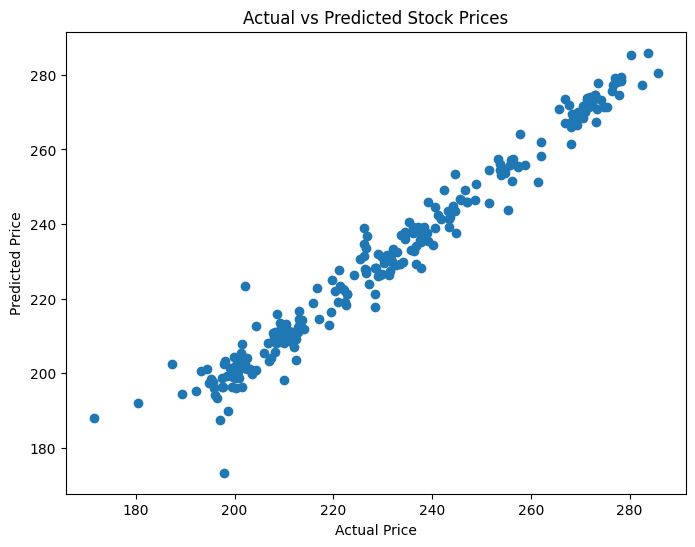

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Stock Prices")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,248.830215,250.625019
1,242.301926,249.115662
2,241.815018,241.407063
3,243.444626,241.452738
4,240.672318,244.494512
5,241.159210,242.358170
6,235.346359,240.466583
7,232.911911,232.611912
8,231.799042,229.858708
9,236.359894,232.641008


In [ ]:
latest_features = X.iloc[-1:]

prediction = model.predict(latest_features)

print("Predicted Next Day Closing Price:")
print(prediction[0])

Predicted Next Day Closing Price:
273.1523247978803


In [ ]:
print("""

FINAL INSIGHTS

1. Historical stock data was downloaded using Yahoo Finance.

2. Open, High, Low, and Volume were used as predictor variables.

3. Linear Regression was trained to predict the next day's closing price.

4. Model performance was evaluated using:
   - MAE
   - RMSE
   - R² Score

5. Predicted values closely followed actual stock prices.

6. This demonstrates how machine learning can be applied to financial forecasting.

""")



FINAL INSIGHTS

1. Historical stock data was downloaded using Yahoo Finance.

2. Open, High, Low, and Volume were used as predictor variables.

3. Linear Regression was trained to predict the next day's closing price.

4. Model performance was evaluated using:
   - MAE
   - RMSE
   - R² Score

5. Predicted values closely followed actual stock prices.

6. This demonstrates how machine learning can be applied to financial forecasting.


